# Dissociation of $H_2$ using GCR-2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyscf.fci
import pyscf.lib
from scipy.sparse.linalg import LinearOperator

from xquces import utils as xq_utils
from xquces.gcr import IGCRSpinRestrictedParameterization, apply_ansatz_parameterization, embed_ansatz_parameters
from xquces.hamiltonians import MolecularHamiltonianLinearOperator
from xquces.optimize.linear_method import minimize_linear_method
from xquces.states import hartree_fock_state

pyscf.lib.num_threads(1)


1

### **1. How to initialize GCR-2 from CCSD $t_1$ and $t_2$ amplitudes**

In [2]:
# Build molecule, run RHF, CCSD and FCI
mol = xq_utils.build_hydrogen_chain(R=0.74, n=2, basis="sto-3g")
mf = xq_utils.run_rhf(mol)
ccsd = xq_utils.run_rccsd(mf)
e_fci, _ = pyscf.fci.FCI(mol, mf.mo_coeff).kernel()

# Construct Hamiltonian as a linear operator
hamiltonian = MolecularHamiltonianLinearOperator.from_scf(mf)
norb = hamiltonian.norb
nelec = hamiltonian.nelec

# Apply GCR2 onto the HF reference state, and take the expectation value of the Hamiltonian
reference = hartree_fock_state(norb, nelec)
igcr = IGCRSpinRestrictedParameterization(norb=norb, nocc=nelec[0], order=2, layers=1)
params = igcr.parameters_from_t_amplitudes(ccsd.t2, t1=ccsd.t1)
state = igcr.ansatz_from_parameters(params).apply(reference, nelec, copy=True)
e_igcr2 = hamiltonian.expectation(state)

print("FCI energy:", e_fci)
print("GCR2 energy:", e_igcr2)


FCI energy: -1.1372838344885023
GCR2 energy: -1.1321800853872568


### **2. How to simulate the variational quantum eigensolver (VQE)**

We initialize the first geometry from CCSD $t_1$ and $t_2$ amplitudes, then optimize GCR-2 with the linear method and analytic state Jacobians. For every later geometry, the previous optimized parameters are transported through the current molecular-orbital frame with `xquces` before optimization. A fresh CCSD seed is kept as a safety net, and we choose it whenever the transported parameters are non-finite or higher in energy.


In [7]:
basis = "sto-3g"
bond_lengths = np.arange(0.4, 4.0 + 0.1, 0.1)  # Angstrom

energies = {
    "FCI": [],
    "HF": [],
    "CCSD": [],
    "GCR2 start": [],
    "GCR2 optimized": [],
}

previous_mol = None
previous_mo_coeff = None
previous_igcr = None
previous_params = None

In [8]:
for R in bond_lengths:
    R = float(R)

    # Build molecule, run RHF, CCSD and FCI
    mol = xq_utils.build_hydrogen_chain(R=R, n=2, basis=basis)
    mf = xq_utils.run_rhf(mol)
    ccsd = xq_utils.run_rccsd(mf)
    e_fci, _ = pyscf.fci.FCI(mol, mf.mo_coeff).kernel()

    # Construct Hamiltonian and GCR2 parameterization
    hamiltonian = MolecularHamiltonianLinearOperator.from_scf(mf)
    H = hamiltonian.as_linear_operator()
    norb = hamiltonian.norb
    nelec = hamiltonian.nelec

    reference = hartree_fock_state(norb, nelec)
    igcr = IGCRSpinRestrictedParameterization(norb=norb, nocc=nelec[0], order=2, layers=1)
    fixed = apply_ansatz_parameterization(igcr, reference, nelec)

    # Initialize the first geometry from CCSD, then transport optimized parameters by MO overlap
    if previous_params is None:
        x0 = igcr.parameters_from_t_amplitudes(ccsd.t2, t1=ccsd.t1)
    else:
        overlap = xq_utils.orbital_overlap_between(previous_mol, previous_mo_coeff, mol, mf.mo_coeff)
        
        x0 = igcr.transfer_parameters_from(previous_params, previous_parameterization=previous_igcr, orbital_overlap=overlap, block_diagonal=True)

    state = fixed.state_from_parameters(x0)
    e_start = hamiltonian.expectation(state)

    # xquces also has an analytic Jacobian
    result = minimize_linear_method(
        fixed.params_to_vec(),
        H,
        x0=x0,
        jac=fixed.state_jacobian_from_parameters,
        maxiter=30,
        gtol=1.0e-7,
        ftol=1.0e-12,
    )
    e_opt = float(result.fun)

    energies["FCI"].append(float(e_fci))
    energies["HF"].append(float(mf.e_tot))
    energies["CCSD"].append(float(ccsd.e_tot))
    energies["GCR2 start"].append(float(e_start))
    energies["GCR2 optimized"].append(e_opt)

    previous_mol = mol
    previous_mo_coeff = np.asarray(mf.mo_coeff, dtype=np.complex128).copy()
    previous_igcr = igcr
    previous_params = np.asarray(result.x, dtype=np.float64).copy()

    print(f"R={R:.2f}  GCR2 start={e_start:.12f}  " f"GCR2 optimized={e_opt:.12f}  FCI={float(e_fci):.12f}")

R=0.40  GCR2 start=-0.911706234825  GCR2 optimized=-0.914149704627  FCI=-0.914149704627
R=0.50  GCR2 start=-1.054792949584  GCR2 optimized=-1.055159794471  FCI=-1.055159794471
R=0.60  GCR2 start=-1.115827134147  GCR2 optimized=-1.116286006870  FCI=-1.116286006870
R=0.70  GCR2 start=-1.135642312662  GCR2 optimized=-1.136189454066  FCI=-1.136189454066
R=0.80  GCR2 start=-1.133513598739  GCR2 optimized=-1.134147666677  FCI=-1.134147666677
R=0.90  GCR2 start=-1.119833566231  GCR2 optimized=-1.120560281300  FCI=-1.120560281300
R=1.00  GCR2 start=-1.100318187865  GCR2 optimized=-1.101150330233  FCI=-1.101150330233
R=1.10  GCR2 start=-1.078242543118  GCR2 optimized=-1.079192944969  FCI=-1.079192944969
R=1.20  GCR2 start=-1.055668976843  GCR2 optimized=-1.056740746305  FCI=-1.056740746305
R=1.30  GCR2 start=-1.034007113380  GCR2 optimized=-1.035186266434  FCI=-1.035186266434
R=1.40  GCR2 start=-1.014215033956  GCR2 optimized=-1.015468249288  FCI=-1.015468249288
R=1.50  GCR2 start=-0.9968713401

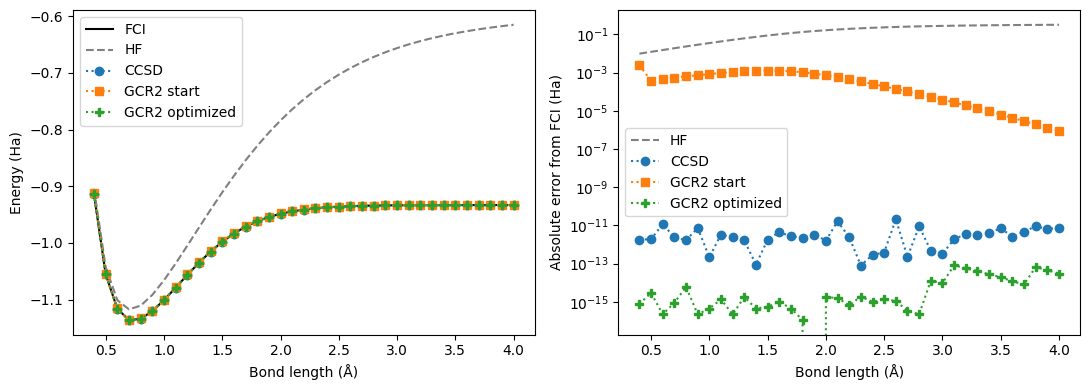

In [20]:
e_fci = np.asarray(energies["FCI"])

fig, (ax_energy, ax_error) = plt.subplots(1, 2, figsize=(11, 4))

ax_energy.plot(bond_lengths, energies["FCI"], color="black", label="FCI")
ax_energy.plot(bond_lengths, energies["HF"], "--", color="gray", label="HF")
ax_energy.plot(bond_lengths, energies["CCSD"], ":o", label="CCSD")
ax_energy.plot(bond_lengths, energies["GCR2 start"], ":s", label="GCR2 start")
ax_energy.plot(bond_lengths, energies["GCR2 optimized"], ":P", label="GCR2 optimized")

ax_energy.set_xlabel("Bond length (Å)")
ax_energy.set_ylabel("Energy (Ha)")
ax_energy.legend()

ax_error.semilogy(bond_lengths, np.abs(np.asarray(energies["HF"]) - e_fci), "--", color="gray", label="HF")
ax_error.semilogy(bond_lengths, np.abs(np.asarray(energies["CCSD"]) - e_fci), ":o", label="CCSD")
ax_error.semilogy(bond_lengths, np.abs(np.asarray(energies["GCR2 start"]) - e_fci), ":s", label="GCR2 start")
ax_error.semilogy(bond_lengths, np.abs(np.asarray(energies["GCR2 optimized"]) - e_fci), ":P", label="GCR2 optimized")

ax_error.set_xlabel("Bond length (Å)")
ax_error.set_ylabel("Absolute error from FCI (Ha)")
ax_error.legend()

plt.tight_layout()
plt.show()

# Dissociation of $H_4$ ring/square for GCR-2, GCR-3 and GCR-4

R=0.80  GCR2=-1.720707201821  GCR3=-1.726515546436  GCR4=-1.726554922778  FCI=-1.728280864171
R=0.90  GCR2=-1.837167450260  GCR3=-1.844824193851  GCR4=-1.845563890932  FCI=-1.846740572821
R=1.00  GCR2=-1.903121298097  GCR3=-1.913070670506  GCR4=-1.913846489125  FCI=-1.915106549512
R=1.10  GCR2=-1.936660413214  GCR3=-1.949474156572  GCR4=-1.950280494565  FCI=-1.951594008074
R=1.20  GCR2=-1.949139938893  GCR3=-1.965391946299  GCR4=-1.966212682410  FCI=-1.967549880292
R=1.30  GCR2=-1.948045457326  GCR3=-1.968234238386  GCR4=-1.969055389618  FCI=-1.970377538398
R=1.40  GCR2=-1.938593077922  GCR3=-1.963006389711  GCR4=-1.963816819666  FCI=-1.965080561230
R=1.50  GCR2=-1.925723845261  GCR3=-1.953172742723  GCR4=-1.953960357766  FCI=-1.955125011600
R=1.60  GCR2=-1.915318172796  GCR3=-1.941155964917  GCR4=-1.941906958226  FCI=-1.942938959988
R=1.70  GCR2=-1.908267714138  GCR3=-1.928629937981  GCR4=-1.929330096592  FCI=-1.930207735544
R=1.80  GCR2=-1.900579258856  GCR3=-1.916701013409  GCR4=-1.

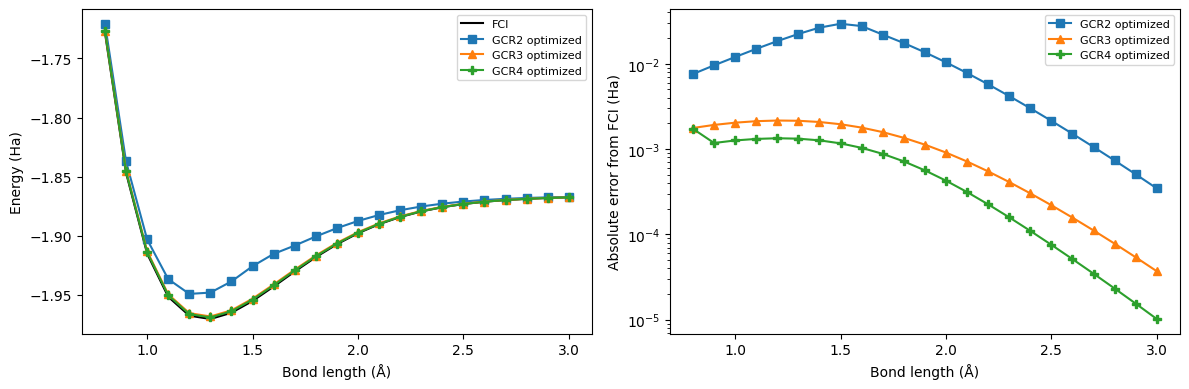

In [4]:
basis = "sto-3g"
bond_lengths_h4 = np.arange(0.8, 3.0 + 0.1, 0.1)  # Angstrom

h4_energies = {
    "FCI": [],
    "HF": [],
    "CCSD": [],
    "GCR2 start": [],
    "GCR2 optimized": [],
    "GCR3 start": [],
    "GCR3 optimized": [],
    "GCR4 start": [],
    "GCR4 optimized": [],
}

previous_mol = None
previous_mo_coeff = None
previous_igcr = {}
previous_params = {}

for R in bond_lengths_h4:
    R = float(R)

    # Build molecule, run RHF, CCSD and FCI
    mol = xq_utils.build_hydrogen_ring(R=R, n=4, basis=basis)
    mf = xq_utils.run_rhf(mol)
    ccsd = xq_utils.run_rccsd(mf)

    # Construct Hamiltonian and compute spin-adapted FCI
    hamiltonian = MolecularHamiltonianLinearOperator.from_scf(mf)
    H = hamiltonian.as_linear_operator()
    norb = hamiltonian.norb
    nelec = hamiltonian.nelec

    fci = pyscf.fci.direct_spin0.FCISolver(mol)
    e_fci, _ = fci.kernel(
        hamiltonian.h1,
        hamiltonian.eri,
        norb,
        nelec,
        ecore=hamiltonian.ecore,
    )

    reference = hartree_fock_state(norb, nelec)
    igcr2 = IGCRSpinRestrictedParameterization(norb=norb, nocc=nelec[0], order=2, layers=1)
    igcr3 = IGCRSpinRestrictedParameterization(norb=norb, nocc=nelec[0], order=3, layers=1)
    igcr4 = IGCRSpinRestrictedParameterization(norb=norb, nocc=nelec[0], order=4, layers=1)

    fixed2 = apply_ansatz_parameterization(igcr2, reference, nelec)
    fixed3 = apply_ansatz_parameterization(igcr3, reference, nelec)
    fixed4 = apply_ansatz_parameterization(igcr4, reference, nelec)

    # Initialize GCR2 from CCSD, then transport optimized parameters by MO overlap
    if previous_mol is None:
        params2 = igcr2.parameters_from_t_amplitudes(ccsd.t2, t1=ccsd.t1)
        overlap = None
    else:
        overlap = xq_utils.orbital_overlap_between(previous_mol, previous_mo_coeff, mol, mf.mo_coeff)
        params2 = igcr2.transfer_parameters_from(previous_params[2], previous_parameterization=previous_igcr[2], orbital_overlap=overlap, block_diagonal=True)

    e_start2 = hamiltonian.expectation(fixed2.state_from_parameters(params2))

    # xquces also has analytic Jacobians for the linear method
    result2 = minimize_linear_method(
        fixed2.params_to_vec(),
        H,
        x0=params2,
        jac=fixed2.state_jacobian_from_parameters,
        maxiter=100,
    )
    e_opt2 = float(result2.fun)

    # On the first geometry, lift the optimized GCR2 ansatz into GCR3
    if previous_mol is None:
        params3 = embed_ansatz_parameters(igcr3, igcr2.ansatz_from_parameters(result2.x))
    else:
        params3 = igcr3.transfer_parameters_from(previous_params[3], previous_parameterization=previous_igcr[3], orbital_overlap=overlap, block_diagonal=True)

    e_start3 = hamiltonian.expectation(fixed3.state_from_parameters(params3))

    result3 = minimize_linear_method(
        fixed3.params_to_vec(),
        H,
        x0=params3,
        jac=fixed3.state_jacobian_from_parameters,
        maxiter=100,
    )
    e_opt3 = float(result3.fun)

    # On the first geometry, lift the optimized GCR3 ansatz into GCR4
    if previous_mol is None:
        params4 = embed_ansatz_parameters(igcr4, igcr3.ansatz_from_parameters(result3.x))
    else:
        params4 = igcr4.transfer_parameters_from(previous_params[4], previous_parameterization=previous_igcr[4], orbital_overlap=overlap, block_diagonal=True)

    e_start4 = hamiltonian.expectation(fixed4.state_from_parameters(params4))

    result4 = minimize_linear_method(
        fixed4.params_to_vec(),
        H,
        x0=params4,
        jac=fixed4.state_jacobian_from_parameters,
        maxiter=100,
    )
    e_opt4 = float(result4.fun)

    h4_energies["FCI"].append(float(e_fci))
    h4_energies["HF"].append(float(mf.e_tot))
    h4_energies["CCSD"].append(float(ccsd.e_tot))
    h4_energies["GCR2 start"].append(float(e_start2))
    h4_energies["GCR2 optimized"].append(e_opt2)
    h4_energies["GCR3 start"].append(float(e_start3))
    h4_energies["GCR3 optimized"].append(e_opt3)
    h4_energies["GCR4 start"].append(float(e_start4))
    h4_energies["GCR4 optimized"].append(e_opt4)

    previous_mol = mol
    previous_mo_coeff = np.asarray(mf.mo_coeff, dtype=np.complex128).copy()
    previous_igcr = {2: igcr2, 3: igcr3, 4: igcr4}
    previous_params = {
        2: np.asarray(result2.x, dtype=np.float64).copy(),
        3: np.asarray(result3.x, dtype=np.float64).copy(),
        4: np.asarray(result4.x, dtype=np.float64).copy(),
    }

    print(
        f"R={R:.2f}  "
        f"GCR2={e_opt2:.12f}  GCR3={e_opt3:.12f}  "
        f"GCR4={e_opt4:.12f}  FCI={float(e_fci):.12f}"
    )


e_h4_fci = np.asarray(h4_energies["FCI"])

fig, (ax_energy, ax_error) = plt.subplots(1, 2, figsize=(12, 4))

ax_energy.plot(bond_lengths_h4, h4_energies["FCI"], color="black", label="FCI")
ax_energy.plot(bond_lengths_h4, h4_energies["GCR2 optimized"], "-s", label="GCR2 optimized")
ax_energy.plot(bond_lengths_h4, h4_energies["GCR3 optimized"], "-^", label="GCR3 optimized")
ax_energy.plot(bond_lengths_h4, h4_energies["GCR4 optimized"], "-P", label="GCR4 optimized")

ax_energy.set_xlabel("Bond length (Å)")
ax_energy.set_ylabel("Energy (Ha)")
ax_energy.legend(fontsize=8)

ax_error.semilogy(bond_lengths_h4, np.abs(np.asarray(h4_energies["GCR2 optimized"]) - e_h4_fci), "-s", label="GCR2 optimized")
ax_error.semilogy(bond_lengths_h4, np.abs(np.asarray(h4_energies["GCR3 optimized"]) - e_h4_fci), "-^", label="GCR3 optimized")
ax_error.semilogy(bond_lengths_h4, np.abs(np.asarray(h4_energies["GCR4 optimized"]) - e_h4_fci), "-P", label="GCR4 optimized")

ax_error.set_xlabel("Bond length (Å)")
ax_error.set_ylabel("Absolute error from FCI (Ha)")
ax_error.legend(fontsize=8)

plt.tight_layout()
plt.show()
